In [1]:
import pandas as pd
import numpy as np
from glob import glob
import os

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

In [2]:
# Load the dataset
daily_data = sorted(glob(r'E:\Project\daily_dataset\daily_dataset/block_*.csv'))
daily_data

# Read and merge all CSV files
daily_data_merge = pd.concat(pd.read_csv(datafile).assign(sourcefilename = datafile)
                             for datafile in daily_data )
daywise_data = daily_data_merge.drop(['sourcefilename'], axis = 1)



In [3]:
# Save the merged DataFrame to a new CSV file
daywise_data.to_csv("E:/Project/Submissions/Datasets/Energy_merged.csv", index=False)

print(f"Merged CSV saved as: Energy_merged.csv")


Merged CSV saved as: Energy_merged.csv


1,048,576
3,510,433
3,034,940

In [4]:
# Load the merged energy dataset
energy_df = pd.read_csv("E:/Project/Submissions/Datasets/Energy_merged.csv")  

# Display basic info
print(energy_df.info())

# Display first few rows
print(energy_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3510433 entries, 0 to 3510432
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   LCLid          object 
 1   day            object 
 2   energy_median  float64
 3   energy_mean    float64
 4   energy_max     float64
 5   energy_count   int64  
 6   energy_std     float64
 7   energy_sum     float64
 8   energy_min     float64
dtypes: float64(6), int64(1), object(2)
memory usage: 241.0+ MB
None
       LCLid         day  energy_median  energy_mean  energy_max  \
0  MAC000002  12-10-2012         0.1385     0.154304       0.886   
1  MAC000002  13-10-2012         0.1800     0.230979       0.933   
2  MAC000002  14-10-2012         0.1580     0.275479       1.085   
3  MAC000002  15-10-2012         0.1310     0.213688       1.164   
4  MAC000002  16-10-2012         0.1450     0.203521       0.991   

   energy_count  energy_std  energy_sum  energy_min  
0            46    0.196034       7.098       0.

In [5]:
# Check for missing values
print(energy_df.isnull().sum())

LCLid                0
day                  0
energy_median       30
energy_mean         30
energy_max          30
energy_count         0
energy_std       11331
energy_sum          30
energy_min          30
dtype: int64


In [6]:
# Check for duplicates
print(energy_df.duplicated().sum())

0


In [7]:
# Check column data types
print(energy_df.dtypes)

LCLid             object
day               object
energy_median    float64
energy_mean      float64
energy_max       float64
energy_count       int64
energy_std       float64
energy_sum       float64
energy_min       float64
dtype: object


In [8]:
# Check basic statistics 
print(energy_df.describe())

       energy_median   energy_mean    energy_max  energy_count    energy_std  \
count   3.510403e+06  3.510403e+06  3.510403e+06  3.510433e+06  3.499102e+06   
mean    1.587395e-01  2.117305e-01  8.345210e-01  4.780364e+01  1.726673e-01   
std     1.701865e-01  1.908460e-01  6.683156e-01  2.810982e+00  1.531208e-01   
min     0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%     6.700000e-02  9.808333e-02  3.460000e-01  4.800000e+01  6.911626e-02   
50%     1.145000e-01  1.632917e-01  6.880000e-01  4.800000e+01  1.327910e-01   
75%     1.910000e-01  2.624583e-01  1.128000e+00  4.800000e+01  2.293124e-01   
max     6.970500e+00  6.928250e+00  1.076100e+01  4.800000e+01  4.024569e+00   

         energy_sum    energy_min  
count  3.510403e+06  3.510403e+06  
mean   1.012414e+01  5.962578e-02  
std    9.128793e+00  8.701312e-02  
min    0.000000e+00  0.000000e+00  
25%    4.682000e+00  2.000000e-02  
50%    7.815000e+00  3.900000e-02  
75%    1.256900e+01  7.1000

In [9]:
# Convert day to a datetime format
energy_df['day'] = pd.to_datetime(energy_df['day'], format='mixed', dayfirst=True)


In [10]:
# Check for missing dates
print(energy_df['day'].isnull().sum())

0


In [11]:
# Sort the dataset by date
energy_df = energy_df.sort_values(by='day')

In [12]:
# Set day as the index
energy_df.set_index('day', inplace=True)


In [13]:
# Drop Rows (Only if Missing Data is Small)
energy_df.dropna(subset=['energy_median', 'energy_mean', 'energy_max', 'energy_sum', 'energy_min'], inplace=True)

In [14]:
# filling with median, missing Data is high)
energy_df['energy_std'].fillna(energy_df['energy_std'].median(), inplace=True)

C:\Users\ABCD\AppData\Local\Temp\ipykernel_12640\3340914052.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  energy_df['energy_std'].fillna(energy_df['energy_std'].median(), inplace=True)


In [15]:
# not essential, dropping it
energy_df.drop(columns=['LCLid'], inplace=True)

In [16]:
# Check for Duplicates
print(energy_df.duplicated().sum())  # Count duplicate rows

29840


In [17]:
# dropping duplicates
energy_df.drop_duplicates(inplace=True)

In [18]:
energy_df

,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
day,,,,,,,
2011-11-23,0.2575,0.298400,0.928,30,0.166282,8.952,0.094
2011-11-23,0.1725,0.248708,0.798,24,0.193996,5.969,0.055
2011-11-23,0.1740,0.252087,0.999,23,0.219155,5.798,0.098
2011-11-23,0.1415,0.125885,0.189,26,0.047938,3.273,0.025
2011-11-23,0.3610,0.352762,0.544,21,0.114464,7.408,0.160
...,...,...,...,...,...,...,...
2014-02-28,4.2190,4.219000,4.219,1,0.132791,4.219,4.219
2014-02-28,0.9670,0.967000,0.967,1,0.132791,0.967,0.967
2014-02-28,0.5600,0.560000,0.560,1,0.132791,0.560,0.560


In [19]:
energy_df.describe()

,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
count,3.480563e+06,3.480563e+06,3.480563e+06,3.480563e+06,3.480563e+06,3.480563e+06,3.480563e+06
mean,1.596994e-01,2.131444e-01,8.412710e-01,4.794170e+01,1.736235e-01,1.021000e+01,5.973649e-02
std,1.703546e-01,1.908315e-01,6.671075e-01,1.198999e+00,1.529821e-01,9.120391e+00,8.690261e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.750000e-02,9.927083e-02,3.520000e-01,4.800000e+01,7.004365e-02,4.756000e+00,2.000000e-02
50%,1.155000e-01,1.643125e-01,6.950000e-01,4.800000e+01,1.335719e-01,7.875000e+00,3.900000e-02
75%,1.920000e-01,2.634583e-01,1.133000e+00,4.800000e+01,2.300390e-01,1.262700e+01,7.100000e-02
max,6.970500e+00,6.928250e+00,1.076100e+01,4.800000e+01,4.024569e+00,3.325560e+02,6.524000e+00


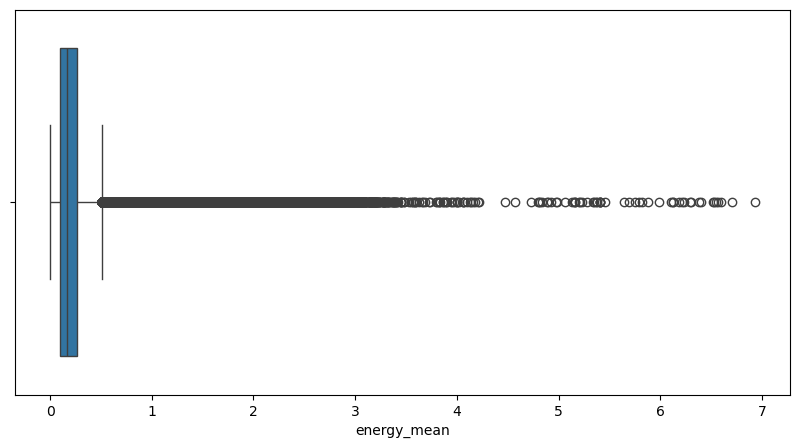

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(x=energy_df["energy_mean"])
plt.show()


# Identifying Outliers using IQR (Interquartile Range)

# Detecting Outliers for energy_mean
Q1 = energy_df["energy_mean"].quantile(0.25)  # First quartile
Q3 = energy_df["energy_mean"].quantile(0.75)  # Third quartile
IQR = Q3 - Q1  # Interquartile range

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = energy_df[(energy_df["energy_mean"] < lower_bound) | (energy_df["energy_mean"] > upper_bound)]
print(f"Number of outliers in energy_mean: {len(outliers)}")


# Removing Outliers
energy_df = energy_df[(energy_df["energy_mean"] >= lower_bound) & (energy_df["energy_mean"] <= upper_bound)]

plt.figure(figsize=(10,5))
sns.boxplot(x=energy_df["energy_mean"])
plt.show()


# List of numerical columns (excluding categorical ones like 'LCLid' and 'day')
num_cols = ["energy_median", "energy_mean", "energy_max", "energy_count", "energy_sum", "energy_std", "energy_min"]

# Dictionary to store outlier counts
outlier_counts = {}

for col in num_cols:
    Q1 = energy_df[col].quantile(0.25)  # First quartile
    Q3 = energy_df[col].quantile(0.75)  # Third quartile
    IQR = Q3 - Q1  # Interquartile range

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = energy_df[(energy_df[col] < lower_bound) | (energy_df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

# Convert to DataFrame and display results
outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=["Column", "Outlier Count"])
print(outlier_df)


In [21]:
def remove_outliers_iqr(df):
    """
    Removes outliers from all numeric columns using the IQR method.
    
    Parameters:
    df (DataFrame): The input DataFrame.

    Returns:
    DataFrame: DataFrame with outliers removed.
    """
    df_clean = df.copy()
    for col in df.select_dtypes(include=[np.number]).columns:  # Select only numeric columns
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Removing outliers
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        print(f"Outliers removed from {col}: {df.shape[0] - df_clean.shape[0]}")
    
    return df_clean

# Apply the function to your dataset
energy_df_clean = remove_outliers_iqr(energy_df)

# Display new summary statistics
print(energy_df_clean.describe())

Outliers removed from energy_median: 223708
Outliers removed from energy_mean: 262279
Outliers removed from energy_max: 305995
Outliers removed from energy_count: 333284
Outliers removed from energy_std: 357691
Outliers removed from energy_sum: 357818
Outliers removed from energy_min: 445623
       energy_median   energy_mean    energy_max  energy_count    energy_std  \
count   3.034940e+06  3.034940e+06  3.034940e+06     3034940.0  3.034940e+06   
mean    1.195962e-01  1.642835e-01  6.998751e-01          48.0  1.412710e-01   
std     7.429663e-02  9.383645e-02  4.636654e-01           0.0  9.759741e-02   
min     0.000000e+00  0.000000e+00  0.000000e+00          48.0  0.000000e+00   
25%     6.300000e-02  9.200000e-02  3.210000e-01          48.0  6.449443e-02   
50%     1.035000e-01  1.473125e-01  6.160000e-01          48.0  1.195930e-01   
75%     1.615000e-01  2.207917e-01  9.860000e-01          48.0  1.977628e-01   
max     3.785000e-01  5.090208e-01  2.304000e+00          48.0  4.7

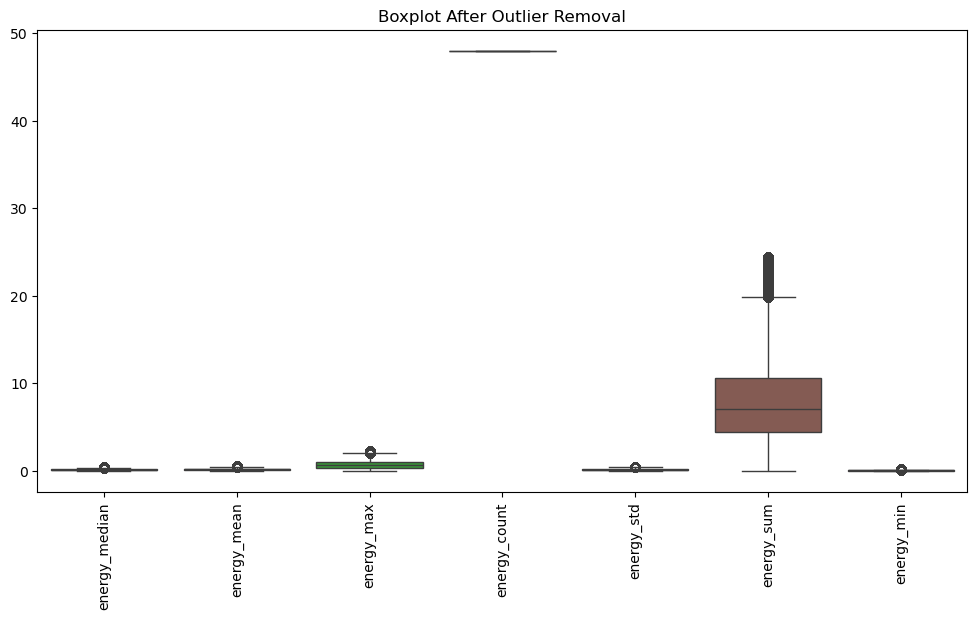

In [22]:
# Visualize the distribution after outlier removal
plt.figure(figsize=(12, 6))
sns.boxplot(data=energy_df_clean)
plt.xticks(rotation=90)
plt.title("Boxplot After Outlier Removal")
plt.show()

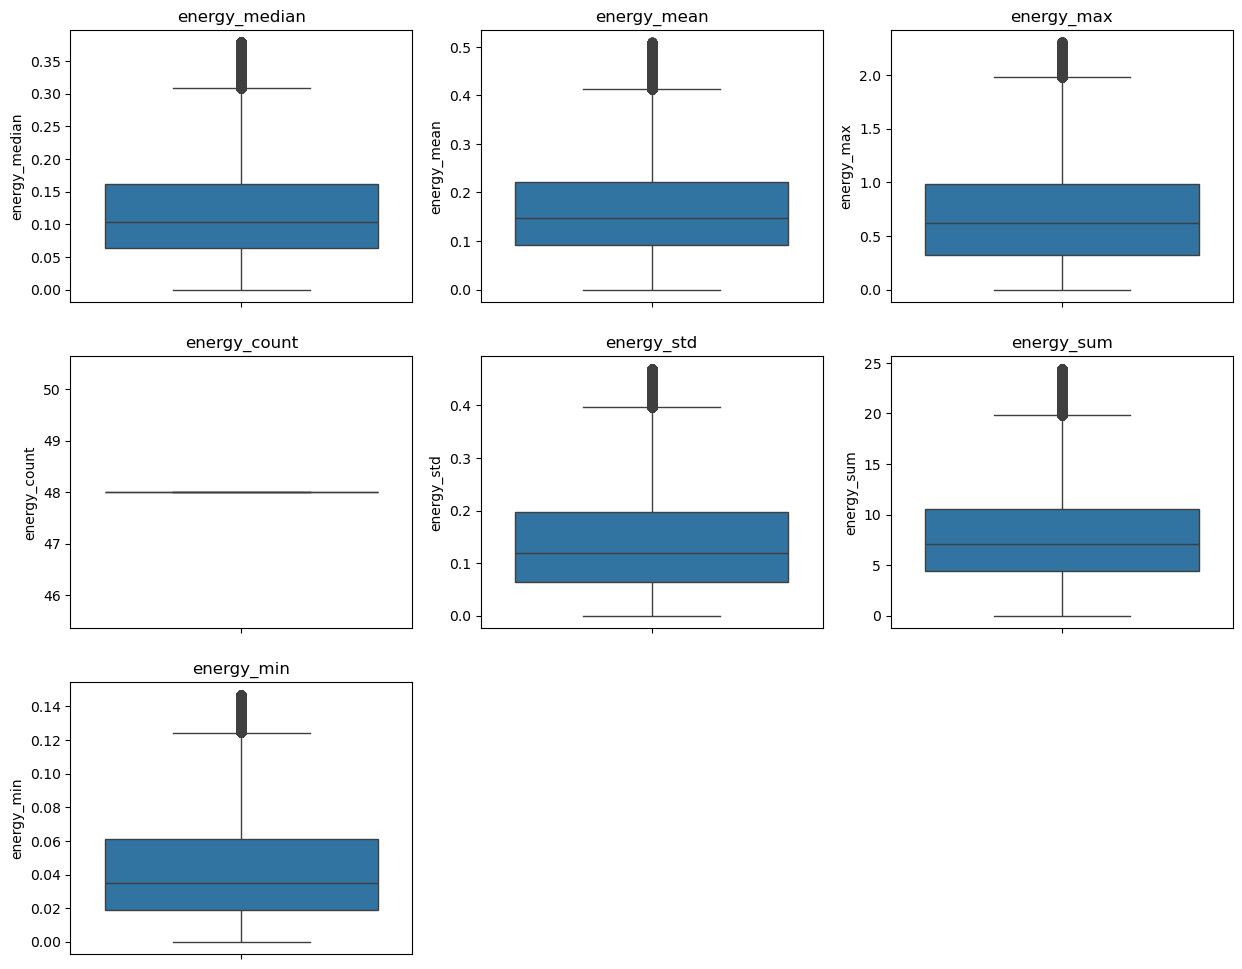

In [23]:
# Select numeric columns
numeric_cols = energy_df_clean.select_dtypes(include=[np.number]).columns

# Define grid size
num_cols = len(numeric_cols)
rows = (num_cols // 3) + (num_cols % 3 > 0)  # Arrange in 3 columns per row

# Create subplots
fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))  # 3 columns per row
axes = axes.flatten()  # Flatten in case of single row

# Generate boxplots for each numeric column
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=energy_df_clean[col], ax=axes[i])
    axes[i].set_title(col)  # Set title as column name

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.show()


In [24]:
print(energy_df_clean["energy_count"].describe())
print(energy_df_clean["energy_count"].nunique())  # Number of unique values


count    3034940.0
mean          48.0
std            0.0
min           48.0
25%           48.0
50%           48.0
75%           48.0
max           48.0
Name: energy_count, dtype: float64
1


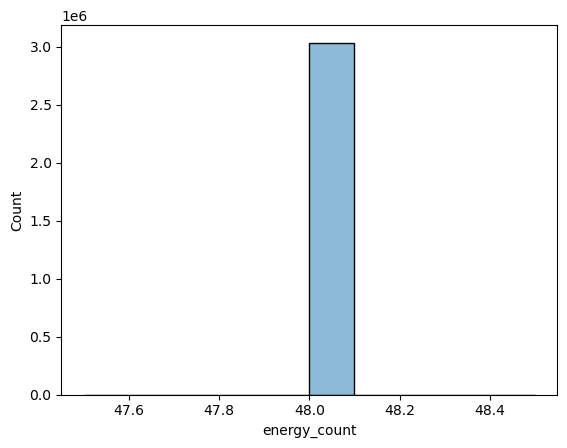

In [25]:
sns.histplot(energy_df_clean["energy_count"], bins=10, kde=True)
plt.show()


In [26]:
energy_df_clean = energy_df_clean.drop(columns=["energy_count"])

In [27]:
energy_df_clean

,energy_median,energy_mean,energy_max,energy_std,energy_sum,energy_min
day,,,,,,
2011-11-24,0.2250,0.252812,0.625,0.135267,12.135,0.092
2011-11-24,0.0480,0.048000,0.049,0.000583,2.304,0.047
2011-11-24,0.1250,0.174875,0.611,0.130562,8.394,0.036
2011-11-24,0.0760,0.096250,0.279,0.068798,4.620,0.023
2011-11-24,0.2910,0.297042,0.769,0.112216,14.258,0.127
...,...,...,...,...,...,...
2014-02-27,0.0020,0.009729,0.038,0.012880,0.467,0.000
2014-02-27,0.0820,0.159812,1.161,0.235171,7.671,0.025
2014-02-27,0.1460,0.211208,0.877,0.228802,10.138,0.023


# Select numeric columns
numeric_cols = energy_df_clean.select_dtypes(include=[np.number]).columns

# Define grid size
num_cols = len(numeric_cols)
rows = (num_cols // 3) + (num_cols % 3 > 0)  # Arrange in 3 columns per row

# Create subplots
fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))  # 3 columns per row
axes = axes.flatten()  # Flatten in case of single row

# Generate boxplots for each numeric column
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=energy_df_clean[col], ax=axes[i])
    axes[i].set_title(col)  # Set title as column name

# Hide unused subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.show()

In [28]:
energy_df_clean.shape

(3034940, 6)

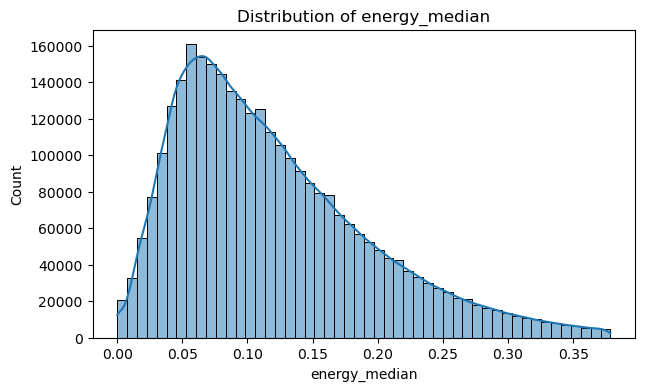

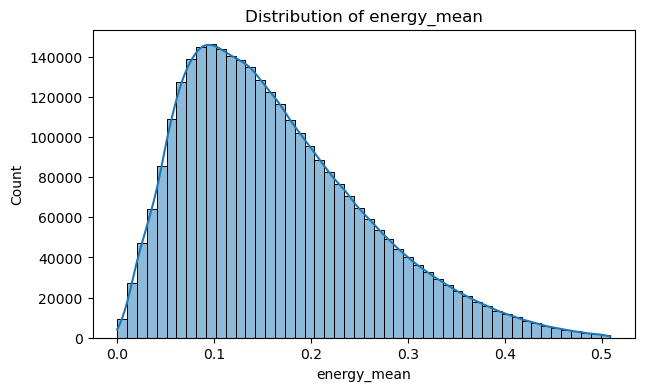

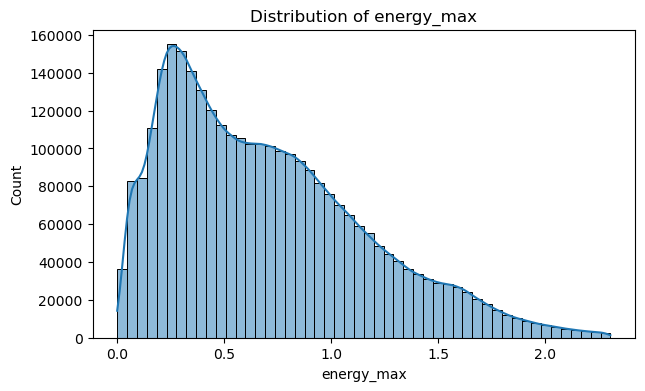

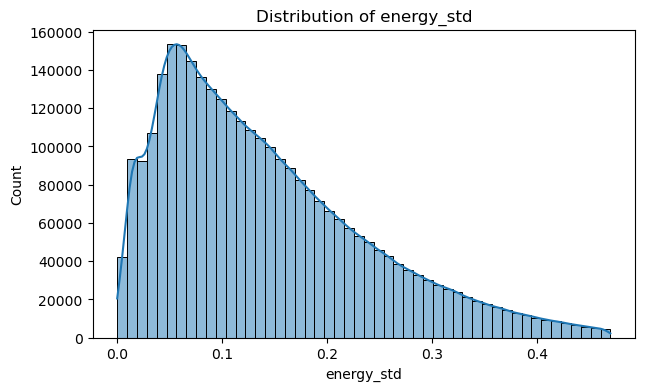

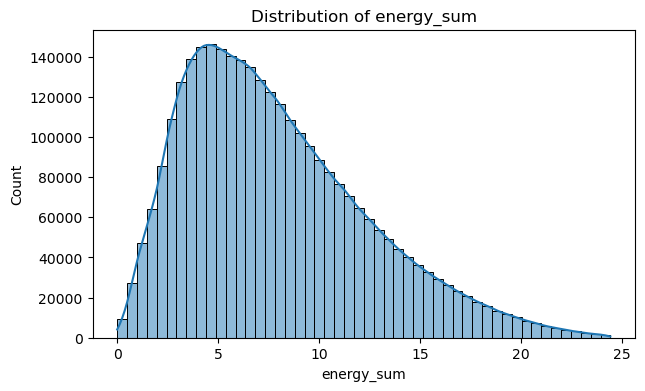

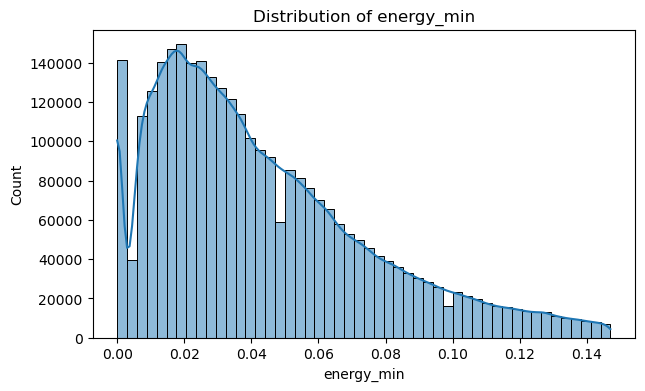

Number of outliers detected: 85316
Dataset size after outlier removal: (3034940, 6)


In [29]:
# Select only numeric columns
numeric_cols = energy_df_clean.select_dtypes(include=np.number).copy()

# Histogram + KDE to check data distribution
for col in numeric_cols.columns[:6]:
    plt.figure(figsize=(7, 4))
    sns.histplot(energy_df_clean[col], kde=True, bins=50)
    plt.title(f"Distribution of {col}")
    plt.show()

# Detect outliers using Z-score
z_scores = np.abs(stats.zscore(numeric_cols))
outlier_mask = (z_scores > 3).any(axis=1)  # Mark rows where any column has a Z-score > 3

# Display outlier count
print(f"Number of outliers detected: {outlier_mask.sum()}")

# Optionally remove outliers
energy_cleaned = energy_df_clean[~outlier_mask]  # Remove rows where any column has a Z-score > 3
print(f"Dataset size after outlier removal: {energy_df_clean.shape}")


In [30]:
energy_cleaned

,energy_median,energy_mean,energy_max,energy_std,energy_sum,energy_min
day,,,,,,
2011-11-24,0.2250,0.252812,0.625,0.135267,12.135,0.092
2011-11-24,0.0480,0.048000,0.049,0.000583,2.304,0.047
2011-11-24,0.1250,0.174875,0.611,0.130562,8.394,0.036
2011-11-24,0.0760,0.096250,0.279,0.068798,4.620,0.023
2011-11-24,0.2910,0.297042,0.769,0.112216,14.258,0.127
...,...,...,...,...,...,...
2014-02-27,0.0020,0.009729,0.038,0.012880,0.467,0.000
2014-02-27,0.0820,0.159812,1.161,0.235171,7.671,0.025
2014-02-27,0.1460,0.211208,0.877,0.228802,10.138,0.023


In [32]:
energy_cleaned = energy_cleaned.reset_index()  # Move 'day' from index to a column
energy_cleaned['day'] = pd.to_datetime(energy_cleaned['day'], errors='coerce')

In [33]:
# Convert 'day' column to datetime, coercing invalid formats to NaT
energy_cleaned['day'] = pd.to_datetime(energy_cleaned['day'], errors='coerce')
energy_cleaned

,day,energy_median,energy_mean,energy_max,energy_std,energy_sum,energy_min
0,2011-11-24,0.2250,0.252812,0.625,0.135267,12.135,0.092
1,2011-11-24,0.0480,0.048000,0.049,0.000583,2.304,0.047
2,2011-11-24,0.1250,0.174875,0.611,0.130562,8.394,0.036
3,2011-11-24,0.0760,0.096250,0.279,0.068798,4.620,0.023
4,2011-11-24,0.2910,0.297042,0.769,0.112216,14.258,0.127
...,...,...,...,...,...,...,...
2949619,2014-02-27,0.0020,0.009729,0.038,0.012880,0.467,0.000
2949620,2014-02-27,0.0820,0.159812,1.161,0.235171,7.671,0.025
2949621,2014-02-27,0.1460,0.211208,0.877,0.228802,10.138,0.023
2949622,2014-02-27,0.0295,0.038000,0.475,0.066159,1.824,0.009


In [34]:
# Save the cleaned energy dataset
energy_cleaned.to_csv("E:/Project/Submissions/Datasets/Energy_processed.csv") 
print(f"\nProcessed dataset saved as: Energy_processed.csv")


Processed dataset saved as: Energy_processed.csv
